In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the prepared dataset
df_final = pd.read_csv('prepared_data.csv')

# Define features and target variables
X = df_final.drop(columns=['NB_Claim', 'AMT_Claim', 'Severity'])
y_claim_frequency = df_final['NB_Claim']
y_severity = df_final['Severity']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=0.95)  # Retain 95% of the variance
X_pca = pca.fit_transform(X_scaled)

# Print the explained variance ratio
print("Explained variance ratio of each component:", pca.explained_variance_ratio_)
print("Number of components selected:", pca.n_components_)


Explained variance ratio of each component: [0.14207321 0.08001947 0.07679562 0.07072152 0.0565301  0.04073288
 0.03547629 0.03010967 0.02498722 0.02318761 0.02196328 0.02089393
 0.01958983 0.01898364 0.01835492 0.01800811 0.01761871 0.01725602
 0.0169293  0.01676997 0.01664762 0.0164787  0.0159319  0.01542062
 0.01521112 0.01442085 0.01394379 0.01335338 0.01269374 0.01219065
 0.01110137 0.01094457 0.01024412 0.00998051]
Number of components selected: 34


In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def calculate_loss_cost(y_freq, y_severity):
    return y_freq * y_severity


In [3]:
from sklearn.linear_model import PoissonRegressor, LinearRegression
from sklearn.model_selection import KFold

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results dictionary for GLM
results_glm_reduced = {
    'Model': 'GLM (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate GLM with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train GLM for claim frequency
    glm_freq = PoissonRegressor()
    glm_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = glm_freq.predict(X_test)
    
    # Train GLM for severity
    glm_severity = LinearRegression()
    glm_severity.fit(X_train, y_train_severity)
    y_pred_severity = glm_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_glm_reduced['RMSE_Frequency'].append(rmse_freq)
    results_glm_reduced['MAE_Frequency'].append(mae_freq)
    results_glm_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_glm_reduced['RMSE_Severity'].append(rmse_severity)
    results_glm_reduced['MAE_Severity'].append(mae_severity)
    results_glm_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_glm_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_glm_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_glm_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_glm_reduced:
    if key != 'Model':
        results_glm_reduced[key] = np.mean(results_glm_reduced[key])

# Print the results
print("GLM Model Results with Reduced Features:")
print(results_glm_reduced)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
GLM Model Results with Reduced Features:
{'Model': 'GLM (Reduced)', 'RMSE_Frequency': 0.21730635224034142, 'MAE_Frequency': 0.08570631622942136, 'R2_Frequency': 0.007119570219634275, 'RMSE_Severity': 1248.689582156795, 'MAE_Severity': 279.2737088004402, 'R2_Severity': 0.015576550427485158, 'RMSE_Loss_Cost': 1481.2172624769373, 'MAE_Loss_Cost': 158.58080705580224, 'R2_Loss_Cost': -0.008313499703657978}


In [9]:
from pygam import LinearGAM, s

# Initialize results dictionary for GAM
results_gam_reduced = {
    'Model': 'GAM (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate GAM with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train GAM for claim frequency
    gam_freq = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5))
    gam_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = gam_freq.predict(X_test)
    
    # Train GAM for severity
    gam_severity = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5))
    gam_severity.fit(X_train, y_train_severity)
    y_pred_severity = gam_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_gam_reduced['RMSE_Frequency'].append(rmse_freq)
    results_gam_reduced['MAE_Frequency'].append(mae_freq)
    results_gam_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_gam_reduced['RMSE_Severity'].append(rmse_severity)
    results_gam_reduced['MAE_Severity'].append(mae_severity)
    results_gam_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_gam_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_gam_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_gam_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_gam_reduced:
    if key != 'Model':
        results_gam_reduced[key] = np.mean(results_gam_reduced[key])

# Print the results
print("GAM Model Results with Reduced Features:")
print(results_gam_reduced)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
GAM Model Results with Reduced Features:
{'Model': 'GAM (Reduced)', 'RMSE_Frequency': 0.2153869496234087, 'MAE_Frequency': 0.08561248801861117, 'R2_Frequency': 0.02455851768843693, 'RMSE_Severity': 1251.1810589482764, 'MAE_Severity': 270.9954888011331, 'R2_Severity': 0.011736064398509804, 'RMSE_Loss_Cost': 1479.9162060745277, 'MAE_Loss_Cost': 160.76936021314003, 'R2_Loss_Cost': -0.00653277572436437}


In [4]:
import xgboost as xgb

# Initialize results dictionary for XGBoost
results_xgboost_reduced = {
    'Model': 'XGBoost (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate XGBoost with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train XGBoost for claim frequency
    xgb_freq = xgb.XGBRegressor(objective='reg:squarederror')
    xgb_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = xgb_freq.predict(X_test)
    
    # Train XGBoost for severity
    xgb_severity = xgb.XGBRegressor(objective='reg:squarederror')
    xgb_severity.fit(X_train, y_train_severity)
    y_pred_severity = xgb_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_xgboost_reduced['RMSE_Frequency'].append(rmse_freq)
    results_xgboost_reduced['MAE_Frequency'].append(mae_freq)
    results_xgboost_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_xgboost_reduced['RMSE_Severity'].append(rmse_severity)
    results_xgboost_reduced['MAE_Severity'].append(mae_severity)
    results_xgboost_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_xgboost_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_xgboost_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_xgboost_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_xgboost_reduced:
    if key != 'Model':
        results_xgboost_reduced[key] = np.mean(results_xgboost_reduced[key])

# Print the results
print("XGBoost Model Results with Reduced Features:")
print(results_xgboost_reduced)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
XGBoost Model Results with Reduced Features:
{'Model': 'XGBoost (Reduced)', 'RMSE_Frequency': 0.1918023475122264, 'MAE_Frequency': 0.07972643905831969, 'R2_Frequency': 0.22624292394100562, 'RMSE_Severity': 1103.7086284195443, 'MAE_Severity': 274.3580840432779, 'R2_Severity': 0.23167815320609017, 'RMSE_Loss_Cost': 1306.9539191096978, 'MAE_Loss_Cost': 150.3296950024344, 'R2_Loss_Cost': 0.21319200593359727}


In [5]:
import lightgbm as lgb

# Initialize results dictionary for LightGBM
results_lightgbm_reduced = {
    'Model': 'LightGBM (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate LightGBM with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train LightGBM for claim frequency
    lgb_freq = lgb.LGBMRegressor(objective='regression')
    lgb_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = lgb_freq.predict(X_test)
    
    # Train LightGBM for severity
    lgb_severity = lgb.LGBMRegressor(objective='regression')
    lgb_severity.fit(X_train, y_train_severity)
    y_pred_severity = lgb_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_lightgbm_reduced['RMSE_Frequency'].append(rmse_freq)
    results_lightgbm_reduced['MAE_Frequency'].append(mae_freq)
    results_lightgbm_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_lightgbm_reduced['RMSE_Severity'].append(rmse_severity)
    results_lightgbm_reduced['MAE_Severity'].append(mae_severity)
    results_lightgbm_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_lightgbm_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_lightgbm_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_lightgbm_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_lightgbm_reduced:
    if key != 'Model':
        results_lightgbm_reduced[key] = np.mean(results_lightgbm_reduced[key])

# Print the results
print("LightGBM Model Results with Reduced Features:")
print(results_lightgbm_reduced)


Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8670
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 34
[LightGBM] [Info] Start training from score 0.044663
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8670
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 34
[LightGBM] [Info] Start training from score 138.745673
Fold 2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8670
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 34
[LightGBM] 

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Initialize results dictionary for Random Forest
results_rf_reduced = {
    'Model': 'Random Forest (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Train and evaluate Random Forest with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train Random Forest for claim frequency
    rf_freq = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = rf_freq.predict(X_test)
    
    # Train Random Forest for severity
    rf_severity = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf_severity.fit(X_train, y_train_severity)
    y_pred_severity = rf_severity.predict(X_test)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_rf_reduced['RMSE_Frequency'].append(rmse_freq)
    results_rf_reduced['MAE_Frequency'].append(mae_freq)
    results_rf_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_rf_reduced['RMSE_Severity'].append(rmse_severity)
    results_rf_reduced['MAE_Severity'].append(mae_severity)
    results_rf_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_rf_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_rf_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_rf_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_rf_reduced:
    if key != 'Model':
        results_rf_reduced[key] = np.mean(results_rf_reduced[key])

# Print the results
print("Random Forest Model Results with Reduced Features:")
print(results_rf_reduced)


Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Random Forest Model Results with Reduced Features:
{'Model': 'Random Forest (Reduced)', 'RMSE_Frequency': 0.2011997505625828, 'MAE_Frequency': 0.07682225101135987, 'R2_Frequency': 0.14874721785854755, 'RMSE_Severity': 1183.3753881364248, 'MAE_Severity': 243.48001734048756, 'R2_Severity': 0.11545072341403573, 'RMSE_Loss_Cost': 1429.4774148022761, 'MAE_Loss_Cost': 156.48081446422685, 'R2_Loss_Cost': 0.06113096641172659}


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor

# Reshape features for LSTM
X_pca_reshaped = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))

# Initialize results dictionary for LSTM
results_lstm_reduced = {
    'Model': 'LSTM (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Function to build the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train and evaluate LSTM with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca_reshaped)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca_reshaped[train_index], X_pca_reshaped[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train LSTM for claim frequency
    lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
    lstm_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = lstm_regressor_freq.predict(X_test)
    
    # Check for NaNs in frequency predictions
    if np.isnan(y_pred_claim_frequency).any():
        print("NaN values found in frequency predictions")
        valid_indices = ~np.isnan(y_pred_claim_frequency)
        y_pred_claim_frequency = y_pred_claim_frequency[valid_indices]
        y_test_freq = y_test_freq.iloc[valid_indices]
    
    # Train LSTM for severity
    lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
    lstm_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = lstm_regressor_severity.predict(X_test)
    
    # Check for NaNs in severity predictions
    if np.isnan(y_pred_severity).any():
        print("NaN values found in severity predictions")
        valid_indices = ~np.isnan(y_pred_severity)
        y_pred_severity = y_pred_severity[valid_indices]
        y_test_severity = y_test_severity.iloc[valid_indices]
    
    # Remove NaNs before calculating metrics
    y_test_freq = np.nan_to_num(y_test_freq)
    y_test_severity = np.nan_to_num(y_test_severity)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_lstm_reduced['RMSE_Frequency'].append(rmse_freq)
    results_lstm_reduced['MAE_Frequency'].append(mae_freq)
    results_lstm_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_lstm_reduced['RMSE_Severity'].append(rmse_severity)
    results_lstm_reduced['MAE_Severity'].append(mae_severity)
    results_lstm_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_lstm_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_lstm_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_lstm_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_lstm_reduced:
    if key != 'Model':
        results_lstm_reduced[key] = np.mean(results_lstm_reduced[key])

# Print the results
print("LSTM Model Results with Reduced Features:")
print(results_lstm_reduced)


Fold 1


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:46: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
2024-07-29 03:56:12.340968: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:58: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 2


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:46: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:58: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 3


...

Fold 4


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:46: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:58: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


Fold 5


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:46: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_freq = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/2105122711.py:58: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  lstm_regressor_severity = KerasRegressor(build_fn=build_lstm_model, input_shape=(X_train.shape[1], X_train.shape[2]), epochs=10, batch_size=32, verbose=0)


LSTM Model Results with Reduced Features:
{'Model': 'LSTM (Reduced)', 'RMSE_Frequency': 0.2157172992401905, 'MAE_Frequency': 0.08315672737350688, 'R2_Frequency': 0.021527216557972472, 'RMSE_Severity': 1253.2392759185643, 'MAE_Severity': 247.24013965699314, 'R2_Severity': 0.008143745650455858, 'RMSE_Loss_Cost': 1480.334281085306, 'MAE_Loss_Cost': 157.60366184662666, 'R2_Loss_Cost': -0.007136685098700602}


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor

# Initialize results dictionary for FFNN
results_ffnn_reduced = {
    'Model': 'Feed-Forward NN (Reduced)',
    'RMSE_Frequency': [],
    'MAE_Frequency': [],
    'R2_Frequency': [],
    'RMSE_Severity': [],
    'MAE_Severity': [],
    'R2_Severity': [],
    'RMSE_Loss_Cost': [],
    'MAE_Loss_Cost': [],
    'R2_Loss_Cost': []
}

# Function to build the FFNN model
def build_ffnn_model(input_shape):
    model = Sequential()
    model.add(Dense(64, input_dim=input_shape[0], activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Train and evaluate FFNN with reduced features
for fold, (train_index, test_index) in enumerate(cv.split(X_pca)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X_pca[train_index], X_pca[test_index]
    y_train_freq, y_test_freq = y_claim_frequency.iloc[train_index], y_claim_frequency.iloc[test_index]
    y_train_severity, y_test_severity = y_severity.iloc[train_index], y_severity.iloc[test_index]
    
    # Ensure no NaNs in target variables
    y_train_freq = y_train_freq.fillna(0)
    y_test_freq = y_test_freq.fillna(0)
    y_train_severity = y_train_severity.fillna(0)
    y_test_severity = y_test_severity.fillna(0)
    
    # Train FFNN for claim frequency
    ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
    ffnn_regressor_freq.fit(X_train, y_train_freq)
    y_pred_claim_frequency = ffnn_regressor_freq.predict(X_test)
    
    # Check for NaNs in frequency predictions
    if np.isnan(y_pred_claim_frequency).any():
        print("NaN values found in frequency predictions")
        valid_indices = ~np.isnan(y_pred_claim_frequency)
        y_pred_claim_frequency = y_pred_claim_frequency[valid_indices]
        y_test_freq = y_test_freq.iloc[valid_indices]
    
    # Train FFNN for severity
    ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
    ffnn_regressor_severity.fit(X_train, y_train_severity)
    y_pred_severity = ffnn_regressor_severity.predict(X_test)
    
    # Check for NaNs in severity predictions
    if np.isnan(y_pred_severity).any():
        print("NaN values found in severity predictions")
        valid_indices = ~np.isnan(y_pred_severity)
        y_pred_severity = y_pred_severity[valid_indices]
        y_test_severity = y_test_severity.iloc[valid_indices]
    
    # Remove NaNs before calculating metrics
    y_test_freq = np.nan_to_num(y_test_freq)
    y_test_severity = np.nan_to_num(y_test_severity)
    
    # Calculate metrics for claim frequency
    rmse_freq, mae_freq, r2_freq = calculate_metrics(y_test_freq, y_pred_claim_frequency)
    results_ffnn_reduced['RMSE_Frequency'].append(rmse_freq)
    results_ffnn_reduced['MAE_Frequency'].append(mae_freq)
    results_ffnn_reduced['R2_Frequency'].append(r2_freq)
    
    # Calculate metrics for severity
    rmse_severity, mae_severity, r2_severity = calculate_metrics(y_test_severity, y_pred_severity)
    results_ffnn_reduced['RMSE_Severity'].append(rmse_severity)
    results_ffnn_reduced['MAE_Severity'].append(mae_severity)
    results_ffnn_reduced['R2_Severity'].append(r2_severity)
    
    # Calculate loss cost and metrics
    actual_loss_cost = calculate_loss_cost(y_test_freq, y_test_severity)
    predicted_loss_cost = calculate_loss_cost(y_pred_claim_frequency, y_pred_severity)
    rmse_loss_cost, mae_loss_cost, r2_loss_cost = calculate_metrics(actual_loss_cost, predicted_loss_cost)
    results_ffnn_reduced['RMSE_Loss_Cost'].append(rmse_loss_cost)
    results_ffnn_reduced['MAE_Loss_Cost'].append(mae_loss_cost)
    results_ffnn_reduced['R2_Loss_Cost'].append(r2_loss_cost)

# Aggregate the results
for key in results_ffnn_reduced:
    if key != 'Model':
        results_ffnn_reduced[key] = np.mean(results_ffnn_reduced[key])

# Print the results
print("Feed-Forward NN Model Results with Reduced Features:")
print(results_ffnn_reduced)


Fold 1


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:43: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:55: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 2


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:43: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:55: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 3


...

Fold 4


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:43: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:55: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Fold 5


/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:43: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_freq = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)
/var/folders/9t/ttq9f0sd08567xh5d9b7lmvw0000gn/T/ipykernel_97423/29313172.py:55: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ffnn_regressor_severity = KerasRegressor(build_fn=build_ffnn_model, input_shape=(X_train.shape[1],), epochs=10, batch_size=32, verbose=0)


Feed-Forward NN Model Results with Reduced Features:
{'Model': 'Feed-Forward NN (Reduced)', 'RMSE_Frequency': 0.2036698603557213, 'MAE_Frequency': 0.08198700837075244, 'R2_Frequency': 0.12759117209233523, 'RMSE_Severity': 1238.463175064226, 'MAE_Severity': 258.7784338977648, 'R2_Severity': 0.03147932902609054, 'RMSE_Loss_Cost': 1456.7186441832494, 'MAE_Loss_Cost': 160.12599267839474, 'R2_Loss_Cost': 0.024212097251803243}


Combined Results with Reduced Features:
                       Model  RMSE_Frequency  MAE_Frequency  R2_Frequency  \
0              GLM (Reduced)        0.217306       0.085706      0.007120   
1              GAM (Reduced)        0.215387       0.085612      0.024559   
2          XGBoost (Reduced)        0.191802       0.079726      0.226243   
3         LightGBM (Reduced)        0.198171       0.075530      0.174126   
4    Random Forest (Reduced)        0.201200       0.076822      0.148747   
5             LSTM (Reduced)        0.215717       0.083157      0.021527   
6  Feed-Forward NN (Reduced)        0.203670       0.081987      0.127591   

   RMSE_Severity  MAE_Severity  R2_Severity  RMSE_Loss_Cost  MAE_Loss_Cost  \
0    1248.689582    279.273709     0.015577     1481.217262     158.580807   
1    1251.181059    270.995489     0.011736     1479.916206     160.769360   
2    1103.708628    274.358084     0.231678     1306.953919     150.329695   
3    1140.664185    246.837724 

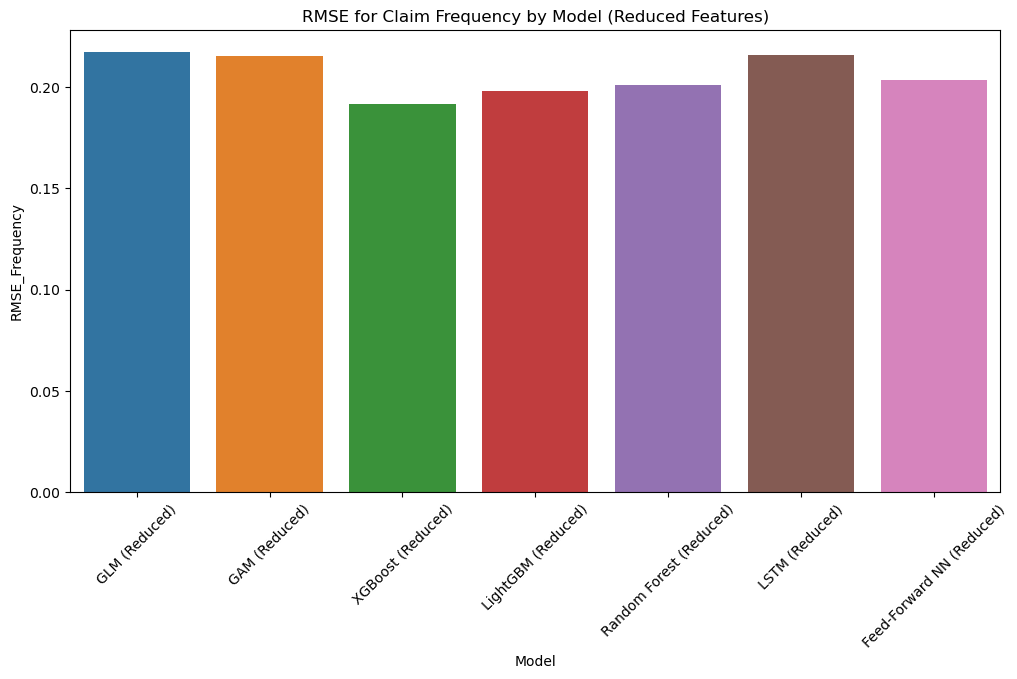

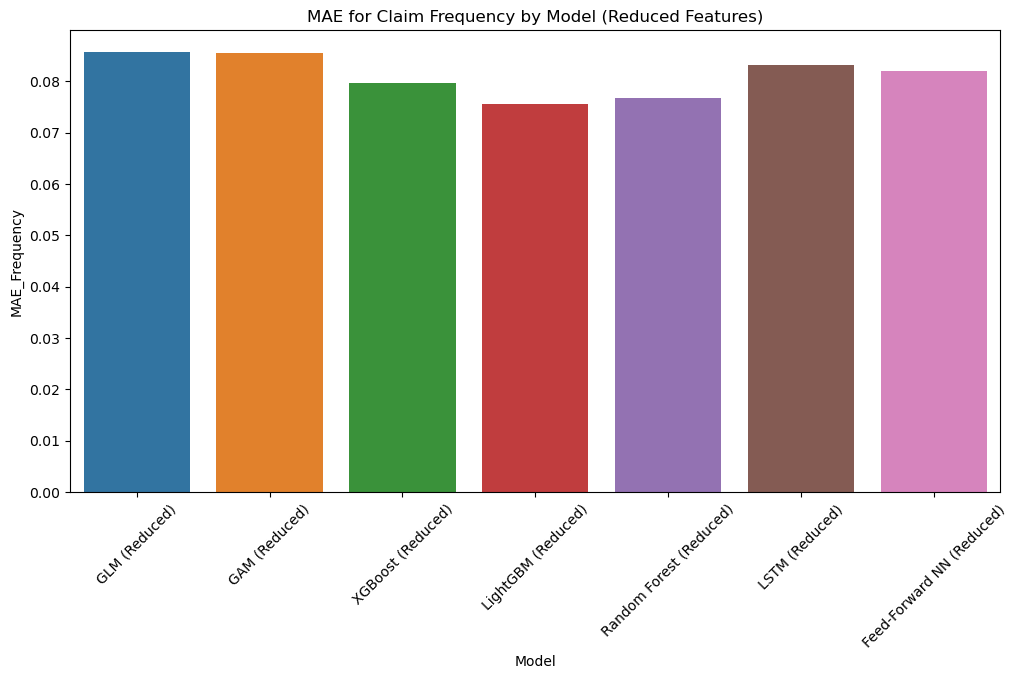

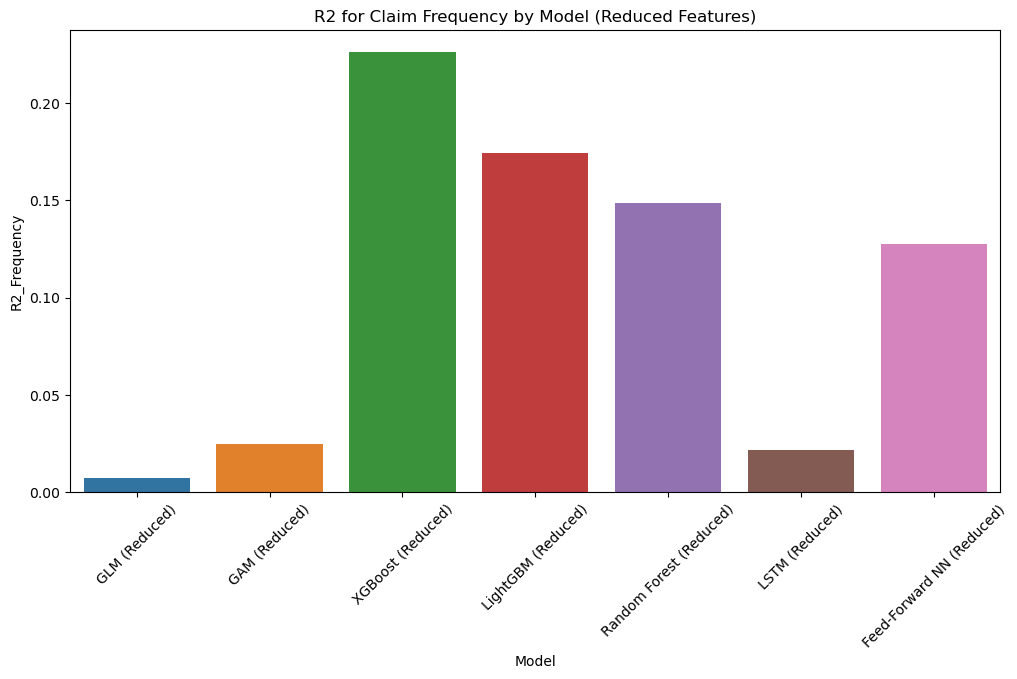

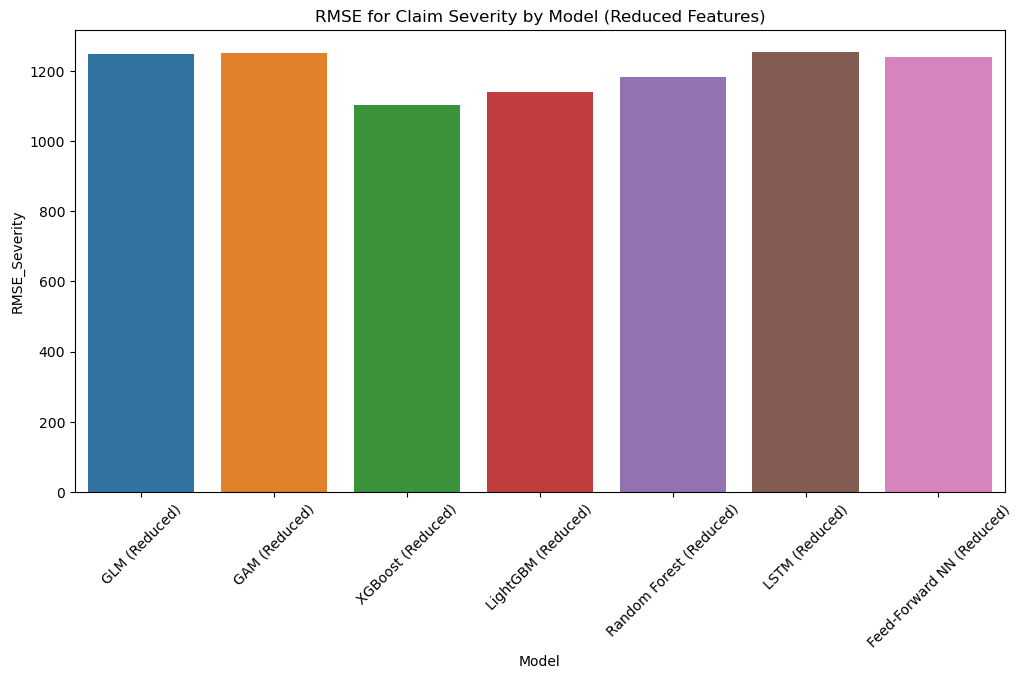

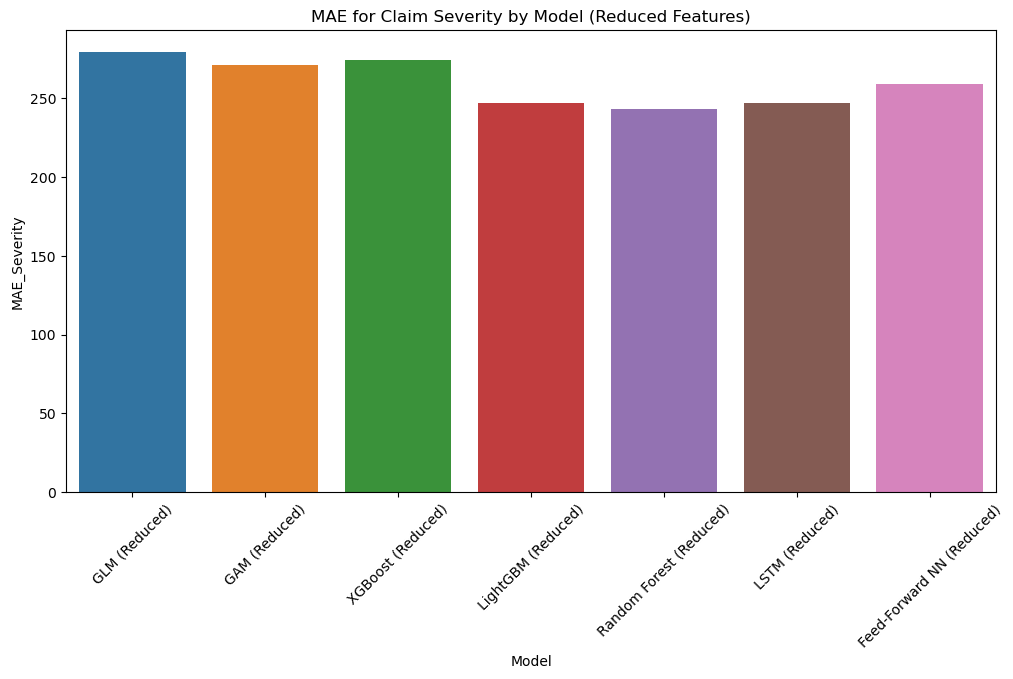

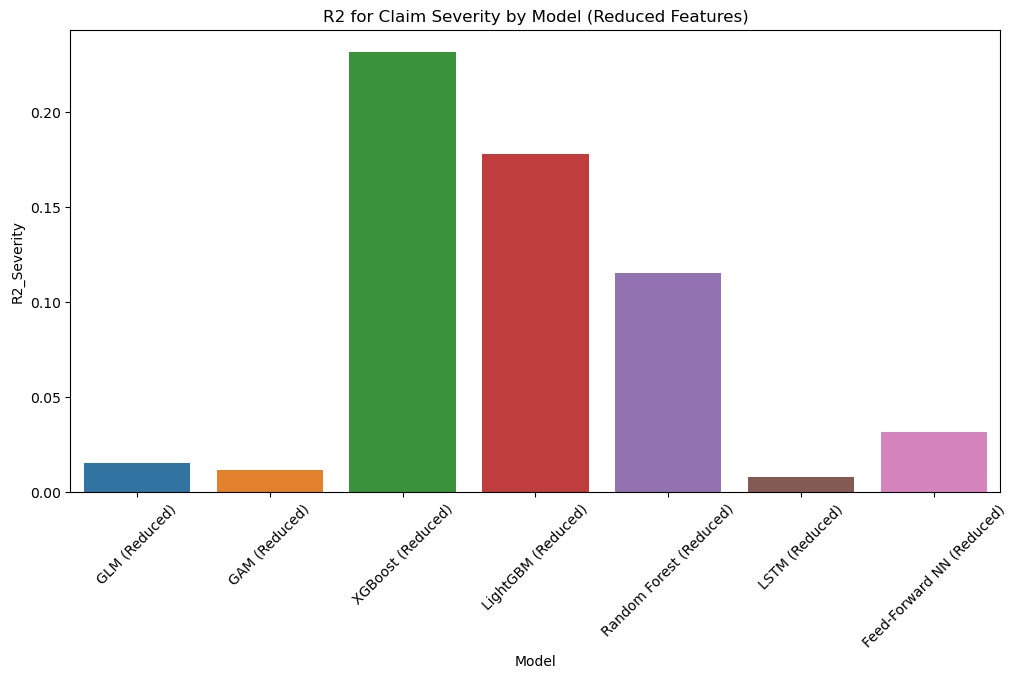

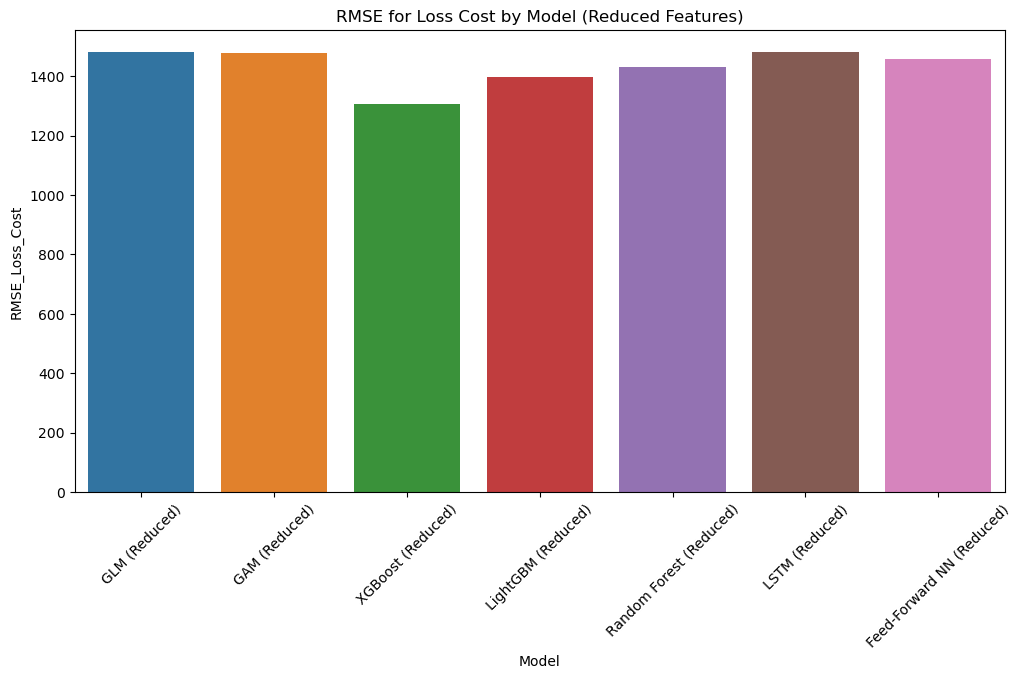

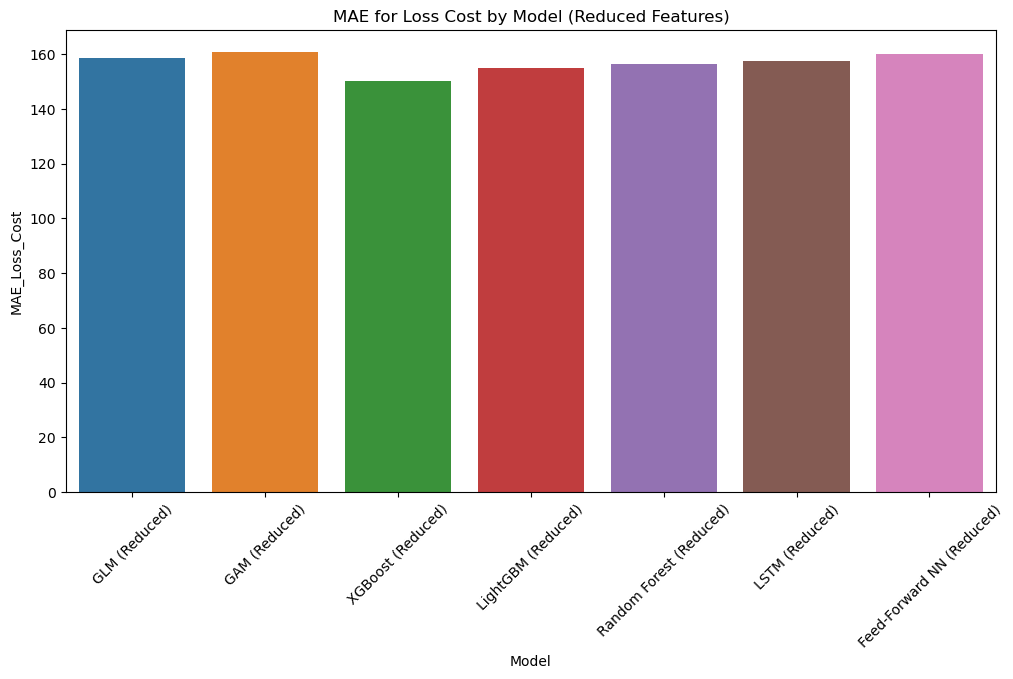

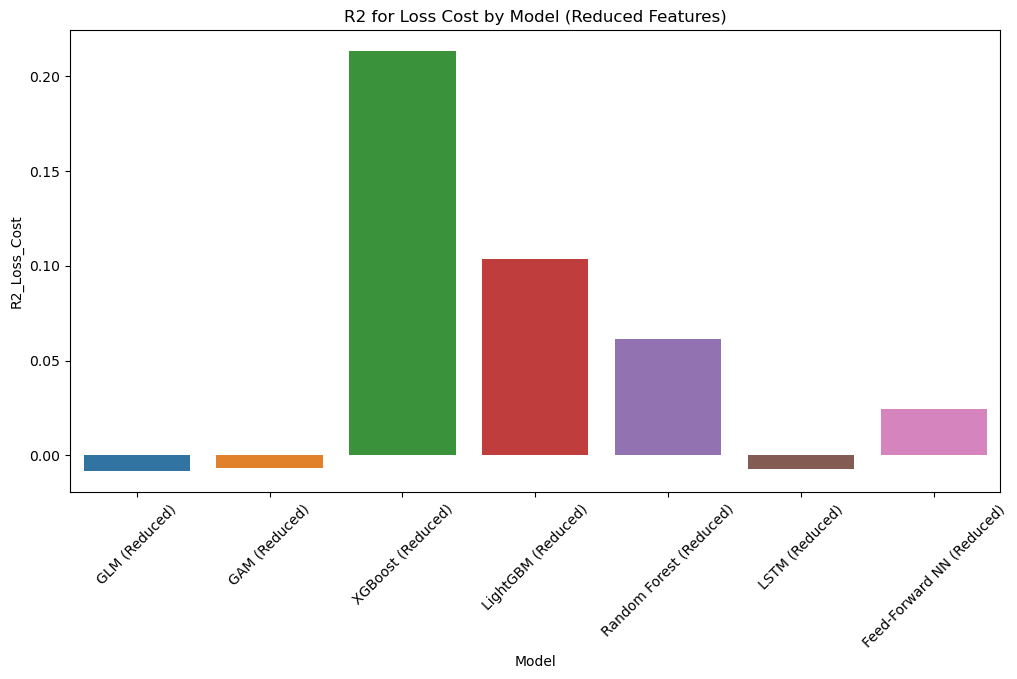

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine results from all models with reduced features into a single DataFrame
results_reduced_combined = pd.DataFrame([
    results_glm_reduced,
    results_gam_reduced,
    results_xgboost_reduced,
    results_lightgbm_reduced,
    results_rf_reduced,
    results_lstm_reduced,
    results_ffnn_reduced
])

# Print the combined results
print("Combined Results with Reduced Features:")
print(results_reduced_combined)

# Save the combined results as a CSV file
results_reduced_combined.to_csv('combined_model_results_reduced_features.csv', index=False)

# Visualization functions
def plot_metrics(metric, title):
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Model', y=metric, data=results_reduced_combined)
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()

# Visualize RMSE for Frequency
plot_metrics('RMSE_Frequency', 'RMSE for Claim Frequency by Model (Reduced Features)')

# Visualize MAE for Frequency
plot_metrics('MAE_Frequency', 'MAE for Claim Frequency by Model (Reduced Features)')

# Visualize R2 for Frequency
plot_metrics('R2_Frequency', 'R2 for Claim Frequency by Model (Reduced Features)')

# Visualize RMSE for Severity
plot_metrics('RMSE_Severity', 'RMSE for Claim Severity by Model (Reduced Features)')

# Visualize MAE for Severity
plot_metrics('MAE_Severity', 'MAE for Claim Severity by Model (Reduced Features)')

# Visualize R2 for Severity
plot_metrics('R2_Severity', 'R2 for Claim Severity by Model (Reduced Features)')

# Visualize RMSE for Loss Cost
plot_metrics('RMSE_Loss_Cost', 'RMSE for Loss Cost by Model (Reduced Features)')

# Visualize MAE for Loss Cost
plot_metrics('MAE_Loss_Cost', 'MAE for Loss Cost by Model (Reduced Features)')

# Visualize R2 for Loss Cost
plot_metrics('R2_Loss_Cost', 'R2 for Loss Cost by Model (Reduced Features)')
